# ======================================================
# Feature Selection using Random Forest Regressor
# ======================================================

# Objective:
# The purpose of this step is to evaluate the importance of all input features
# (including both SCATS and AADT datasets) in predicting the target variable
# `traffic_volume`.

# Explanation:
# We use a Random Forest Regressor model to measure how much each feature
# contributes to the prediction. This method provides a feature importance score
# for every variable in the dataset.

# Why this is important:
# - Features with very low importance do not significantly affect the model's output.
# - Removing these features helps reduce data dimensionality.
# - This leads to faster training and can improve model performance by reducing noise.

# Expected outcome:
# After calculating feature importance, we will:
# 1. Identify less important features.
# 2. Remove them from the dataset.
# 3. Keep only the most relevant features for the next modeling steps.

In [25]:
# ======================================================
# 1. IMPORT LIBRARIES
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

print("Libraries loaded.")

Libraries loaded.


In [26]:
# ======================================================
# 2. LOAD DATA
# ======================================================
print("Loading dataset...")

data_path = "../data/processed/master_dataset.csv"
df = pd.read_csv(data_path, low_memory=False)

print(f"Dataset shape: {df.shape}")

Loading dataset...
Dataset shape: (396480, 35)


In [27]:
# ======================================================
# 3. CLEAN TARGET (VERY IMPORTANT)
# ======================================================
# Convert traffic_volume -> numeric (fix lỗi 'SCATS')
df['traffic_volume'] = pd.to_numeric(df['traffic_volume'], errors='coerce')

df = df.dropna(subset=['traffic_volume'])

print("Target cleaned.")

Target cleaned.


In [28]:
# ======================================================
# 4. SPLIT X, y
# ======================================================
print("Preparing X and y...")

y = df['traffic_volume']

cols_to_drop = ['date', 'datetime', 'traffic_volume']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns]).copy()

print(f"X shape: {X.shape}")

Preparing X and y...
X shape: (396480, 32)


In [29]:
# ======================================================
# 5. HANDLE MISSING + ENCODE
# ======================================================
print("Cleaning & encoding data...")

label_encoders = {}

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna("UNKNOWN")
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
    else:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        X[col] = X[col].fillna(0)

print("Data ready for training.")

Cleaning & encoding data...


Data ready for training.


In [30]:
# ======================================================
# 6. TRAIN MODEL
# ======================================================
print("Training Random Forest...")

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

print("Training done.")

Training Random Forest...


Training done.


Calculating feature importance...


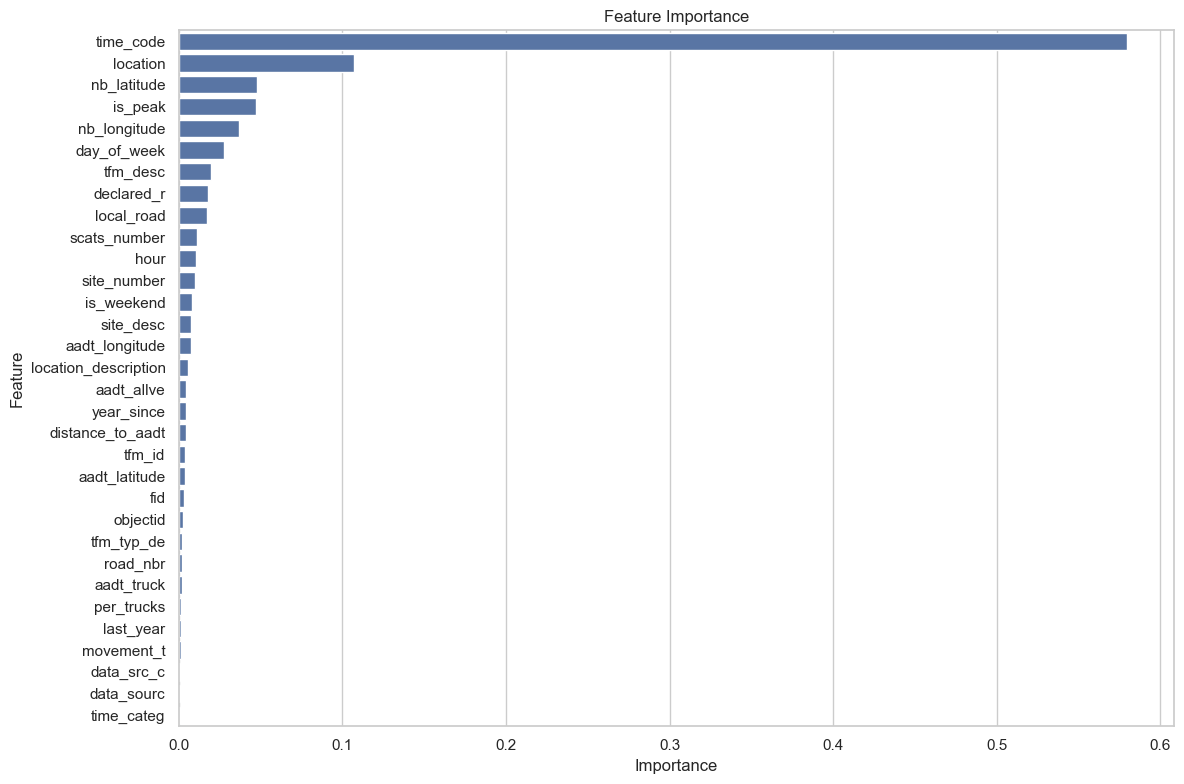

In [31]:
# ======================================================
# 7. FEATURE IMPORTANCE
# ======================================================
print("Calculating feature importance...")

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance")
plt.show()

In [32]:
# ======================================================
# 8. FEATURE SELECTION
# ======================================================
threshold = 0.01

important = importance_df[importance_df['Importance'] >= threshold]
useless = importance_df[importance_df['Importance'] < threshold]

print(f"Important features: {len(important)}")
print(important['Feature'].tolist())

print(f"\nRemoved features: {len(useless)}")

Important features: 12
['time_code', 'location', 'nb_latitude', 'is_peak', 'nb_longitude', 'day_of_week', 'tfm_desc', 'declared_r', 'local_road', 'scats_number', 'hour', 'site_number']

Removed features: 20


In [33]:
# ======================================================
# 9. CREATE FINAL DATASET
# ======================================================
print("Creating final dataset...")

final_cols = [
    "scats_number", 
    "location", 
    "declared_r",
    "nb_latitude", 
    "nb_longitude", 
    "datetime",
    "hour", 
    "day_of_week", 
    "is_weekend", 
    "is_peak", 
    "traffic_volume"
]

df_final = df[final_cols].copy()

df_final = df_final.rename(columns={"declared_r": "road_name"})

# Save
output_path = "../data/processed/2006_processed.csv"
df_final.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Final shape: {df_final.shape}")

Creating final dataset...


Saved: ../data/processed/2006_processed.csv
Final shape: (396480, 11)
